# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-18: HR PhysNet v2 - SNR loss + PhysDrive experiment 

### What this notebook does
Trains the PhysNet HR model (identical architecture to NB_P3_08) twice, back-to-back, on ONE fixed subject-wise split, and compares the two runs. It documents two things at once: the effect of the **2026 SNR frequency loss** (better cross-dataset generalization than a plain frequency-match term) and the effect of **adding the PhysDrive corpus** to training.

### The two configs
- **`baseline`** - trains on MCD + DLCN + UBFC-rPPG (the v1 screen corpus) with the v2 SNR-loss recipe. PhysDrive appears in eval only = zero-shot. Comparing its shared-dataset MAE to the v1 screen (7.31, old loss, same corpus) isolates the SNR-loss effect.
- **`plus_physdrive`** - adds PhysDrive to training. Comparing it to `baseline` isolates the PhysDrive-as-training effect.



### Clean-comparison rules
- **One fixed split** (seed 42) across all four datasets, so the eval set is identical for both runs; only the training composition changes.
- **Both models select on the shared MCD+DLCN+UBFC MAE**, so PhysDrive's large zero-shot variance never drives checkpointing.
- Loss = `neg_pearson` + `LAMBDA_SNR * snr_loss` (in-band SNR at the reference fundamental + first harmonic, per-sample fps, invalid-HR clips masked), each clip weighted by `cardiac_sqi`.


## 1. Imports & Config

In [1]:
import os, time, random, gc
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

#  locate the four Phase-3 datasets across Kaggle inputs (PhysDrive may be a separate upload) ---
WANT = ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
H5_PATHS = []
for name in WANT:
    hits = list(Path('/kaggle/input').rglob(name))
    if hits:
        H5_PATHS.append(hits[0])
print('datasets found:', [p.name for p in H5_PATHS])

#  experiment: the two configs run in this notebook 
CONFIGS = ['baseline', 'plus_physdrive']
TRAIN_DATASETS = {
    'baseline':       {'MCD', 'DLCN', 'UBFC-rPPG'},
    'plus_physdrive': {'MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive'},
}
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'}   # checkpoint metric (PhysDrive excluded from selection)
V1_SCREEN = {'MCD': 10.69, 'DLCN': 3.24, 'UBFC-rPPG': 2.80}  # PhysNet v1 (old loss, no PhysDrive); shared ALL 7.31

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 8
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
LAMBDA_SNR = 0.05
HR_LOW, HR_HIGH = 0.66, 3.0

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| configs:', CONFIGS)

datasets found: ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
device: cuda | configs: ['baseline', 'plus_physdrive']


## 2. Data Loader — index, one fixed subject-split

In [2]:
def build_index(h5_paths, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for path in h5_paths:
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=str(path), group=name, dataset=str(a.get('dataset', Path(path).stem)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))


index = build_index(H5_PATHS)
train_all, val_idx, val_subj = subject_split(index)   # ONE fixed split, shared by both configs
print('usable:', len(index), 'by dataset:', dict(Counter(r['dataset'] for r in index)))
print('val (FIXED):', len(val_idx), 'by dataset:', dict(Counter(r['dataset'] for r in val_idx)))

usable: 2276 by dataset: {'MCD': 1191, 'DLCN': 777, 'UBFC-rPPG': 42, 'PhysDrive': 266}
val (FIXED): 475 by dataset: {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}


## 3. Model — PhysNet (identical to NB_P3_08)

In [3]:
class PhysNet(nn.Module):
    '''PhysNet 3D-CNN encoder-decoder (Yu et al. 2019): [B,3,T,H,W] -> BVP [B,T].'''
    def __init__(self, frames=CLIP_LEN):
        super().__init__()
        self.frames = frames

        def block(cin, cout):
            return nn.Sequential(nn.Conv3d(cin, cout, (3, 3, 3), stride=1, padding=1),
                                 nn.BatchNorm3d(cout), nn.ReLU(inplace=True))

        self.b1 = nn.Sequential(nn.Conv3d(3, 16, (1, 5, 5), stride=1, padding=(0, 2, 2)),
                                nn.BatchNorm3d(16), nn.ReLU(inplace=True))
        self.b2 = block(16, 32); self.b3 = block(32, 64)
        self.b4 = block(64, 64); self.b5 = block(64, 64)
        self.b6 = block(64, 64); self.b7 = block(64, 64)
        self.b8 = block(64, 64); self.b9 = block(64, 64)
        self.up1 = nn.Sequential(nn.ConvTranspose3d(64, 64, (4, 1, 1), stride=(2, 1, 1), padding=(1, 0, 0)),
                                 nn.BatchNorm3d(64), nn.ELU(inplace=True))
        self.up2 = nn.Sequential(nn.ConvTranspose3d(64, 64, (4, 1, 1), stride=(2, 1, 1), padding=(1, 0, 0)),
                                 nn.BatchNorm3d(64), nn.ELU(inplace=True))
        self.poolspa = nn.AdaptiveAvgPool3d((frames, 1, 1))
        self.out = nn.Conv3d(64, 1, (1, 1, 1), stride=1, padding=0)
        self.maxpool_spa = nn.MaxPool3d((1, 2, 2))
        self.maxpool_spatem = nn.MaxPool3d((2, 2, 2))

    def forward(self, x):
        x = self.b1(x); x = self.maxpool_spa(x)
        x = self.b2(x); x = self.b3(x); x = self.maxpool_spatem(x)
        x = self.b4(x); x = self.b5(x); x = self.maxpool_spatem(x)
        x = self.b6(x); x = self.b7(x); x = self.maxpool_spa(x)
        x = self.b8(x); x = self.b9(x)
        x = self.up1(x); x = self.up2(x)
        x = self.poolspa(x); x = self.out(x)
        return x.view(x.shape[0], self.frames)

## 4. Losses & Evaluation

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader):
    '''Returns dict with overall MAE, shared (MCD+DLCN+UBFC) MAE, per-dataset MAE, and r.'''
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = model(frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        return dict(all=1e9, shared=1e9, per={}, r=float('nan'), n=0)
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    per = df.groupby('dataset')['ae'].mean().round(3).to_dict()
    shared = df[df.dataset.isin(SHARED_DATASETS)]['ae']
    return dict(all=float(df.ae.mean()),
                shared=float(shared.mean()) if len(shared) else float(df.ae.mean()),
                per=per, n=int(len(df)),
                r=float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan'))

## 5. One-config trainer
Trains one config for the full schedule, checkpoints on the shared (MCD+DLCN+UBFC) MAE, and returns its history and best-epoch per-dataset metrics.

In [5]:
def run_config(cfg):
    train_idx = [r for r in train_all if r['dataset'] in TRAIN_DATASETS[cfg]]
    train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
    val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
    print(f'[{cfg}] train recs {len(train_idx)} by ds {dict(Counter(r["dataset"] for r in train_idx))} | clips/epoch {len(train_loader.dataset)}')

    torch.manual_seed(SEED)                        # same init for both configs
    model = PhysNet(frames=CLIP_LEN).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = GradScaler('cuda')
    ckpt = f'physnet_v2_{cfg}_best.pt'
    best = 1e9; best_per = {}; best_all = None; best_epoch = -1; hist = []
    for epoch in range(EPOCHS):
        model.train(); t0 = time.time()
        for batch in train_loader:
            frames = batch['frames'].to(device, non_blocking=True)
            bvp = batch['bvp'].to(device, non_blocking=True)
            sqi = batch['sqi'].to(device, non_blocking=True)
            hr = batch['hr'].to(device, non_blocking=True)
            fps = batch['fps'].to(device, non_blocking=True)
            valid = ((hr >= 40) & (hr <= 180)).float()
            opt.zero_grad(set_to_none=True)
            with autocast('cuda'):
                pred = model(frames)
            pred = pred.float()
            per_loss = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
            w = sqi.clamp(min=1e-3)
            loss = (per_loss * w).sum() / w.sum()
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        sched.step()
        res = evaluate(model, val_loader)
        hist.append({'epoch': epoch + 1, 'shared': res['shared'], 'all': res['all'], 'r': res['r'],
                     **{f'mae_{k}': v for k, v in res['per'].items()}})
        print(f'  [{cfg}] ep{epoch + 1}/{EPOCHS} | {time.time() - t0:.0f}s | shared {res["shared"]:.2f} | all {res["all"]:.2f} | {res["per"]}')
        if res['shared'] < best:
            best = res['shared']; best_per = res['per']; best_all = res['all']; best_epoch = epoch + 1
            torch.save(model.state_dict(), ckpt); print('     * new best shared', round(best, 2))
    del model, opt, train_loader, val_loader; gc.collect(); torch.cuda.empty_cache()
    print(f'[{cfg}] DONE | best shared MAE {best:.2f} @ep{best_epoch} | per-dataset {best_per}')
    return dict(cfg=cfg, ckpt=ckpt, best_shared=best, best_all=best_all, best_epoch=best_epoch,
                best_per=best_per, history=pd.DataFrame(hist))

## 6. Run both configs (back-to-back, ~6 h total)

In [6]:
results = {}
for cfg in CONFIGS:
    print('=' * 70, cfg)
    results[cfg] = run_config(cfg)

for cfg in CONFIGS:
    results[cfg]['history'].to_csv(f'history_{cfg}.csv', index=False)
print('\nboth runs complete:', {c: round(results[c]['best_shared'], 2) for c in CONFIGS})

====================================================================== baseline
[baseline] train recs 1603 by ds {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35} | clips/epoch 3206
  [baseline] ep1/30 | 466s | shared 27.53 | all 26.26 | {'DLCN': 20.96, 'MCD': 32.104, 'PhysDrive': 18.695, 'UBFC-rPPG': 33.367}
     * new best shared 27.53
  [baseline] ep2/30 | 419s | shared 23.07 | all 22.16 | {'DLCN': 24.911, 'MCD': 21.52, 'PhysDrive': 16.71, 'UBFC-rPPG': 30.173}
     * new best shared 23.07
  [baseline] ep3/30 | 391s | shared 24.75 | all 23.98 | {'DLCN': 22.299, 'MCD': 26.584, 'PhysDrive': 19.357, 'UBFC-rPPG': 22.608}
  [baseline] ep4/30 | 393s | shared 15.68 | all 15.82 | {'DLCN': 18.08, 'MCD': 13.773, 'PhysDrive': 16.71, 'UBFC-rPPG': 21.058}
     * new best shared 15.68
  [baseline] ep5/30 | 393s | shared 18.86 | all 19.19 | {'DLCN': 17.545, 'MCD': 19.645, 'PhysDrive': 21.176, 'UBFC-rPPG': 24.182}
  [baseline] ep6/30 | 399s | shared 34.72 | all 33.35 | {'DLCN': 39.241, 'MCD': 30.834, 'Phys

## 7. Comparison — baseline vs plus_physdrive (best-checkpoint per-dataset)

In [7]:
order = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']
tab = []
for d in order:
    tab.append({'dataset': d, 'v1_screen': V1_SCREEN.get(d, np.nan),
                'baseline': results['baseline']['best_per'].get(d, np.nan),
                'plus_physdrive': results['plus_physdrive']['best_per'].get(d, np.nan)})
comp = pd.DataFrame(tab).set_index('dataset')
comp.loc['shared-3 (ckpt metric)'] = [7.31, results['baseline']['best_shared'], results['plus_physdrive']['best_shared']]
comp.loc['ALL (incl PhysDrive)'] = [np.nan, results['baseline']['best_all'], results['plus_physdrive']['best_all']]
comp['delta_+physdrive'] = (comp['plus_physdrive'] - comp['baseline']).round(2)

print('PhysNet v2 comparison (HR MAE, bpm) - PhysDrive is zero-shot in baseline, in-domain in plus_physdrive')
print(comp.round(2).to_string())
print('\nReads:')
print('  v1_screen -> baseline (shared-3)   = the SNR-loss effect on the original corpus')
print('  baseline  -> plus_physdrive (shared) = what adding PhysDrive does to the clean sets')
print('  PhysDrive row                       = the hard in-vehicle benchmark (zero-shot vs in-domain)')

PhysNet v2 comparison (HR MAE, bpm) - PhysDrive is zero-shot in baseline, in-domain in plus_physdrive
                        v1_screen  baseline  plus_physdrive  delta_+physdrive
dataset                                                                      
MCD                         10.69      6.84           13.98              7.14
DLCN                         3.24      3.08           11.52              8.44
UBFC-rPPG                    2.80      3.13           22.61             19.47
PhysDrive                     NaN     27.79           19.19             -8.60
shared-3 (ckpt metric)       7.31      5.22           13.11              7.89
ALL (incl PhysDrive)          NaN      8.45           13.98              5.53

Reads:
  v1_screen -> baseline (shared-3)   = the SNR-loss effect on the original corpus
  baseline  -> plus_physdrive (shared) = what adding PhysDrive does to the clean sets
  PhysDrive row                       = the hard in-vehicle benchmark (zero-shot vs in-domain)


## 8. Per-config evaluation & Bland-Altman

====================================================================== baseline | zero-shot: ['PhysDrive']
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0   3.08   9.19   0.40   -17.64     18.44       0.80
MCD        232.0   6.83  15.05   0.45   -29.10     30.01       0.54
PhysDrive   68.0  27.79  38.20  24.82   -32.53     82.16       0.11
UBFC-rPPG    7.0   3.13   5.86  -3.13   -13.63      7.36       0.97
ALL        475.0   8.45  18.71   3.87   -32.04     39.78       0.42


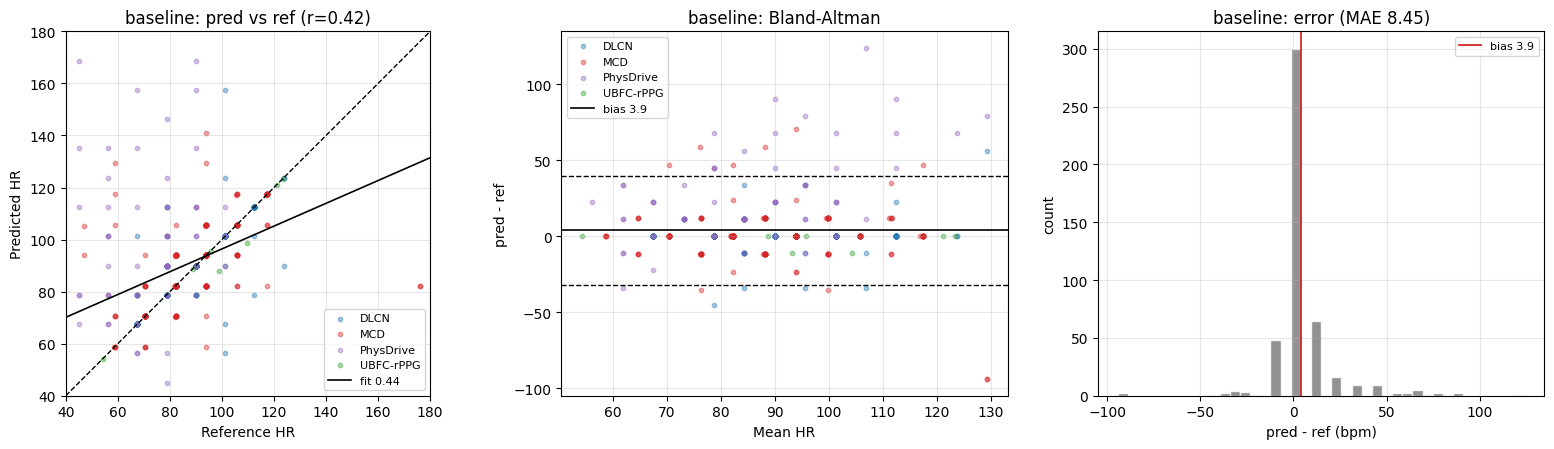

====================================================================== plus_physdrive | zero-shot: []
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0  11.52  14.78   0.67   -28.36     29.70       0.00
MCD        232.0  13.97  18.95  -1.93   -38.96     35.11       0.04
PhysDrive   68.0  19.19  23.55  14.89   -21.14     50.92      -0.14
UBFC-rPPG    7.0  22.61  25.54 -13.31   -59.46     32.85       0.15
ALL        475.0  13.98  18.49   1.23   -34.96     37.42       0.01


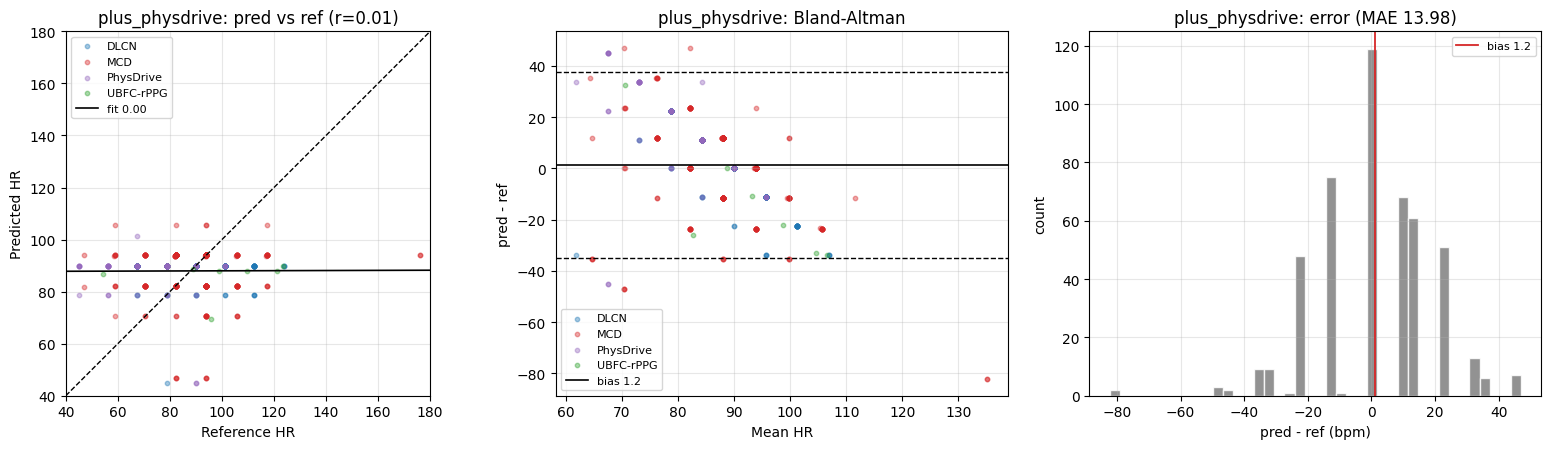

In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_predictions(model, loader):
    rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = model(frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])

def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series({'n': len(g), 'MAE': np.abs(d).mean(), 'RMSE': np.sqrt((d ** 2).mean()),
                     'bias': d.mean(), 'LoA_low': d.mean() - 1.96 * sd, 'LoA_high': d.mean() + 1.96 * sd,
                     'Pearson_r': np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan})

colors = {'MCD': 'tab:red', 'DLCN': 'tab:blue', 'UBFC-rPPG': 'tab:green', 'PhysDrive': 'tab:purple'}
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)

for cfg in CONFIGS:
    model = PhysNet(frames=CLIP_LEN).to(device)
    model.load_state_dict(torch.load(results[cfg]['ckpt'], map_location=device)); model.eval()
    pred_df = collect_predictions(model, val_loader)
    summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
    overall = metrics_block(pred_df); overall.name = 'ALL'
    zs = [d for d in summary.index if d not in TRAIN_DATASETS[cfg]]
    print('=' * 70, cfg, '| zero-shot:', zs)
    print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

    diff = (pred_df.hr_pred - pred_df.hr_true).values
    bias, sd = diff.mean(), diff.std(ddof=1)
    r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
    lim = [40, 180]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
    for ds, g in pred_df.groupby('dataset'):
        ax[0].scatter(g.hr_true, g.hr_pred, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
    ax[0].plot(lim, lim, 'k--', lw=1)
    sl, ic = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
    ax[0].plot(np.array(lim), ic + sl * np.array(lim), 'k-', lw=1.2, label=f'fit {sl:.2f}')
    ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR', ylabel='Predicted HR',
              title=f'{cfg}: pred vs ref (r={r:.2f})', aspect='equal'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
    for ds, g in pred_df.groupby('dataset'):
        ax[1].scatter((g.hr_true + g.hr_pred) / 2, g.hr_pred - g.hr_true, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
    ax[1].axhline(bias, color='k', lw=1.2, label=f'bias {bias:.1f}')
    ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1); ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1)
    ax[1].set(xlabel='Mean HR', ylabel='pred - ref', title=f'{cfg}: Bland-Altman'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
    ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
    ax[2].axvline(bias, color='tab:red', lw=1.3, label=f'bias {bias:.1f}')
    ax[2].set(xlabel='pred - ref (bpm)', ylabel='count', title=f'{cfg}: error (MAE {np.abs(diff).mean():.2f})'); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    del model; gc.collect(); torch.cuda.empty_cache()

## 9. Discussion and conclusions

This notebook ran one controlled comparison on a fixed subject-wise split: `baseline`
(MCD + DLCN + UBFC-rPPG, v2 SNR-loss recipe) and `plus_physdrive` (the same plus the
PhysDrive corpus), both selected on the shared MCD+DLCN+UBFC MAE and evaluated on the
identical four-dataset held-out set. Two conclusions follow.

**The SNR frequency loss is a substantial win.** On the unchanged v1 corpus, `baseline`
reaches a shared-dataset MAE of 5.22 bpm against the v1 screen's 7.31, and MCD - the
noisy pulse-ox reference that capped every v1 architecture at ~10-11 bpm and that the
Optuna search could not move (7.31 -> 7.24) - drops to 6.84 from 10.69, with DLCN also
improving (3.08 vs 3.24). Concentrating predicted power at the reference fundamental and
ignoring the rest of the band is exactly the property that tolerates a noisy reference,
so the largest gain landing on MCD is consistent with the mechanism. This is the phase's
HR improvement, on the same data, from the loss alone.

**Adding PhysDrive to training is harmful; it is retained as evaluation-only.**
`plus_physdrive` failed to learn even the clean sets (best shared MAE 13.11, more than
double `baseline`) and then diverged in the second half of training (shared MAE climbing
past 35). Folding in the small, motion-corrupted in-vehicle corpus destabilizes learning
and wrecks the clean datasets while only marginally improving PhysDrive's own error
(27.8 zero-shot -> 19.2 in-domain, still unusable). PhysDrive is therefore confirmed as a
hard in-vehicle held-out benchmark rather than a training source.

**PhysDrive as a benchmark.** Even the best model scores 27.8 bpm on PhysDrive zero-shot
with a large positive bias - facial rPPG under real driving motion and dynamic light
reads vehicle and mouth motion as a faster pulse. This is the honest real-world failure
the benchmark is meant to expose.
